In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

from geoai.utils_ds.PreProcessingOps import PreProcessingOperations
from geoai.utils_ds.VisualizeOps import VisualizeOperations
from geoai.utils_ml.ModelOps import ModelOperations


pre_ops = PreProcessingOperations()
vis_ops = VisualizeOperations()
model_ops = ModelOperations()

In [2]:
X_train = pd.read_csv("csv_files/X_train_fe.csv")
X_test = pd.read_csv("csv_files/X_test_fe.csv")
y_train = pd.read_csv("csv_files/y_train.csv")
y_test = pd.read_csv("csv_files/y_test.csv")
X_train.head(1)

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,BLUE^2,BLUE GREEN,...,SWIR REI,NDVI^2,NDVI NDBI,NDVI REI,NDBI^2,NDBI REI,REI^2,NDVI_bin_non_veg,NDVI_bin_veg,NDVI_dis_encoded
0,373.5,519.5,389.0,3034.0,1991.0,0.772714,-0.207562,0.002342,139502.25,194033.25,...,4.661945,0.597087,-0.160386,0.001809,0.043082,-0.000486,0.000005,0,1,2


In [3]:
# scale the data
X_train_fe_scaled, X_test_fe_scaled = pre_ops.scale_to_minmax(X_train, X_test)
X_train_fe_scaled.head(1)

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,BLUE^2,BLUE GREEN,...,SWIR REI,NDVI^2,NDVI NDBI,NDVI REI,NDBI^2,NDBI REI,REI^2,NDVI_bin_non_veg,NDVI_bin_veg,NDVI_dis_encoded
0,0.01238,0.020718,0.023453,0.615321,0.141552,0.941447,0.12174,0.883081,0.001893,0.002796,...,0.903032,0.882198,0.253733,0.844985,0.404388,0.207416,0.779808,0.0,1.0,1.0


In [4]:
# compute for PCA  explained variance
var_exp, cum_var_exp = pre_ops.compute_pca_variance(X_train_fe_scaled)

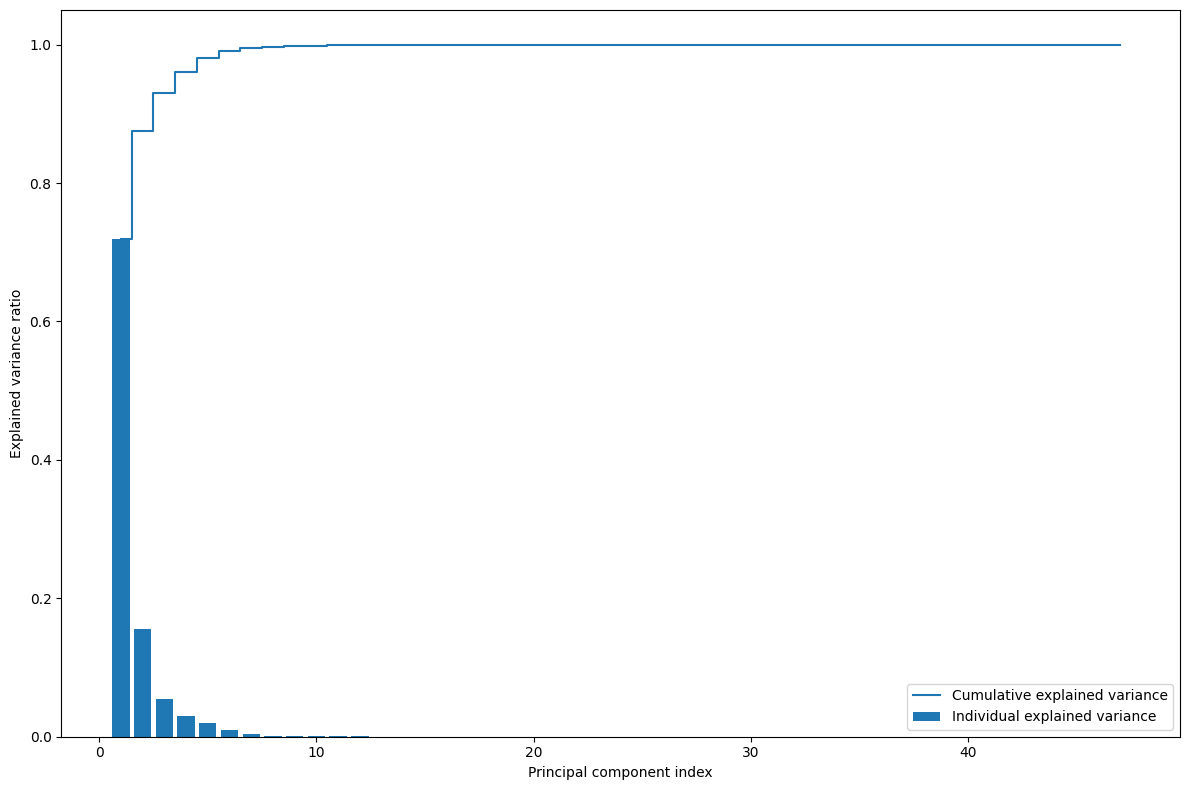

array([0.71911335, 0.87534189, 0.93049514, 0.96103325, 0.9812002 ,
       0.99131825, 0.99466562, 0.99615396, 0.99727433, 0.99807409,
       0.99871889, 0.99907873, 0.9993624 , 0.99953005, 0.99965455,
       0.99975279, 0.99983682, 0.99989016, 0.99992597, 0.99995472,
       0.9999718 , 0.99997885, 0.99998387, 0.99998839, 0.99999141,
       0.99999369, 0.9999958 , 0.99999697, 0.99999802, 0.99999872,
       0.99999912, 0.99999938, 0.99999959, 0.9999997 , 0.9999998 ,
       0.99999987, 0.99999993, 0.99999998, 0.99999998, 0.99999999,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        ])

In [5]:
# plot the explained variance
vis_ops.plot_explained_variance_ratio(var_exp, cum_var_exp, X_train_fe_scaled.shape[1] + 1)
cum_var_exp

In [16]:
# apply_pca using 4 components
X_train_pca, X_test_pca = pre_ops.apply_pca(X_train_fe_scaled, X_test_fe_scaled, n_components=9)
# fit the model using the pca data
lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_pca, y_train.values.ravel())

# predict the validation set
y_train_pred = lr.predict(X_train_pca)
y_pred_test = lr.predict(X_test_pca)

# calculate the accuracy
print(f"Train Accuracy: {model_ops.calculate_classification_accuracy(y_train, y_train_pred)}")
print(f"Test Accuracy: {model_ops.calculate_classification_accuracy(y_test, y_pred_test)}")

Train Accuracy: (0.9198966408268734, 0.9231337781158774, 0.9198966408268734, 0.920485793314132)
Test Accuracy: (0.9111570247933884, 0.9141963550351554, 0.9111570247933884, 0.9117720133066353)


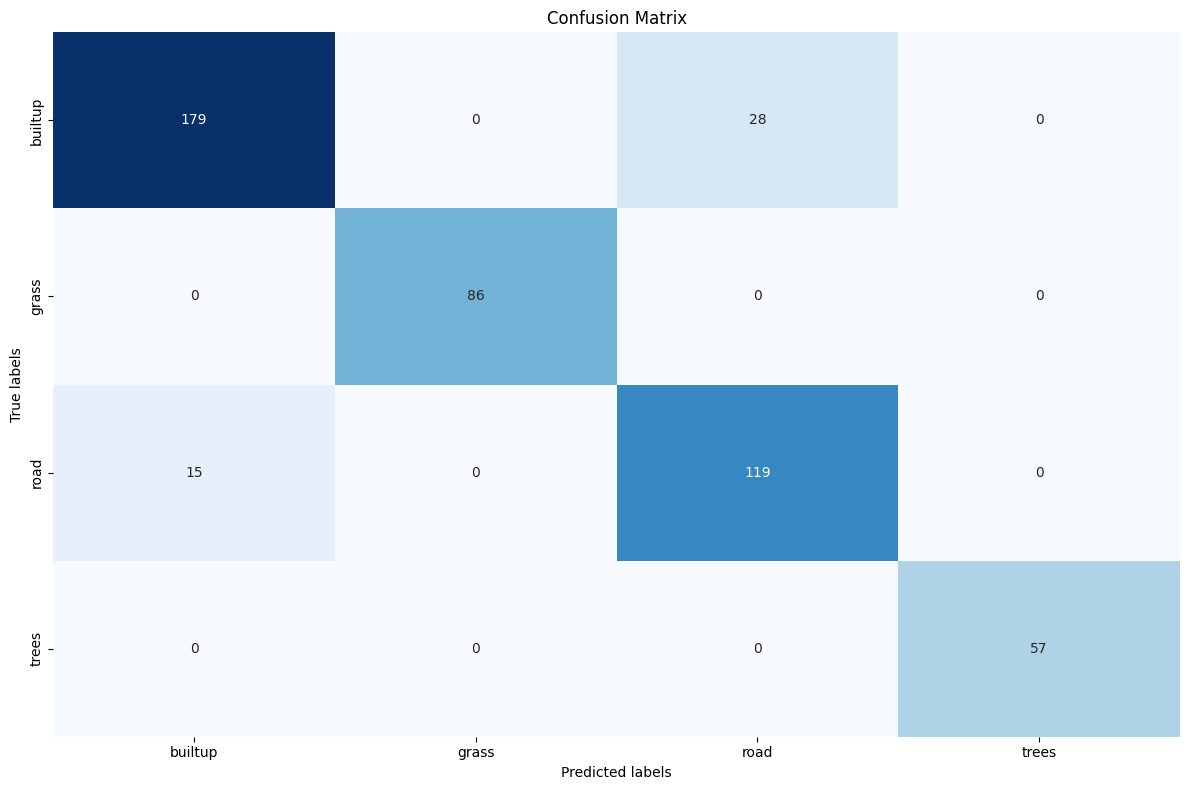

In [17]:
label_mapping = {0: 'builtup', 1: 'grass', 2: 'road', 3: 'trees'}
class_names_str = [label_mapping[label] for label in lr.classes_]
vis_ops.plot_confusion_matrix(y_test, y_pred_test, class_names_str)